In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/CICIOT23/train/train.csv')

In [3]:
df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [4]:
df.shape

(5491971, 47)

In [5]:
df.columns

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491971 entries, 0 to 5491970
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             float64
 20  HTTPS            float64
 21  DNS              float64
 22  Telnet           float64
 23  SMTP             float64
 24  SSH              float64
 25  IRC              float64
 26  TCP              float64
 27  UDP         

In [7]:
df['label'].unique()

array(['DDoS-ACK_Fragmentation', 'DDoS-SYN_Flood', 'DDoS-PSHACK_Flood',
       'Mirai-greeth_flood', 'DoS-SYN_Flood', 'DDoS-ICMP_Flood',
       'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'Mirai-greip_flood',
       'BenignTraffic', 'Mirai-udpplain', 'DoS-TCP_Flood',
       'DDoS-SynonymousIP_Flood', 'DoS-UDP_Flood', 'DDoS-RSTFINFlood',
       'Recon-HostDiscovery', 'DDoS-UDP_Fragmentation',
       'DDoS-ICMP_Fragmentation', 'DDoS-HTTP_Flood', 'MITM-ArpSpoofing',
       'Recon-PortScan', 'DNS_Spoofing', 'DoS-HTTP_Flood',
       'DDoS-SlowLoris', 'DictionaryBruteForce', 'VulnerabilityScan',
       'Recon-OSScan', 'Recon-PingSweep', 'XSS', 'CommandInjection',
       'Backdoor_Malware', 'SqlInjection', 'BrowserHijacking',
       'Uploading_Attack'], dtype=object)

In [8]:
df['label'].value_counts()

,count
label,
DDoS-ICMP_Flood,848088
DDoS-UDP_Flood,637558
DDoS-TCP_Flood,528499
DDoS-PSHACK_Flood,481254
DDoS-SYN_Flood,478653
DDoS-RSTFINFlood,475441
DDoS-SynonymousIP_Flood,422083
DoS-UDP_Flood,390422
DoS-TCP_Flood,314174


In [9]:
print(df.isnull().sum())

flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
label              0
dtype: int64


In [10]:
df.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,...,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06
mean,5.657345e+00,7.687147e+04,9.066457e+00,6.636141e+01,9.049942e+03,9.049942e+03,3.229612e-06,8.650082e-02,2.071142e-01,9.042418e-02,...,1.247361e+02,3.341244e+01,1.247348e+02,8.319404e+07,9.499002e+00,1.312450e+01,4.721960e+01,3.076685e+04,9.657527e-02,1.415261e+02
std,2.749157e+02,4.615005e+05,8.943837e+00,1.406518e+01,9.986400e+04,9.986400e+04,1.848825e-03,2.811022e-01,4.052381e-01,2.867885e-01,...,2.411282e+02,1.604832e+02,2.416016e+02,1.706512e+07,8.201925e-01,8.632303e+00,2.269779e+02,3.208097e+05,2.332437e-01,2.109219e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.093860e+00,2.093860e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307157e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.578598e+01,1.578598e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.050286e-01,3.001300e+02,1.444000e+01,6.400000e+01,1.178755e+02,1.178755e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.405011e+01,3.719096e-01,5.406000e+01,8.334391e+07,9.500000e+00,1.039671e+01,5.059213e-01,1.344216e+00,8.000000e-02,1.415500e+02
max,9.943576e+04,9.890105e+06,4.700000e+01,2.550000e+02,8.388608e+06,8.388608e+06,2.679210e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.160047e+04,9.302373e+03,1.309800e+04,1.676394e+08,1.500000e+01,1.453904e+02,1.315554e+04,9.670837e+07,1.000000e+00,2.446000e+02


/tmp/ipykernel_471/2858356607.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_labels.values, y=top_labels.index, palette='viridis')


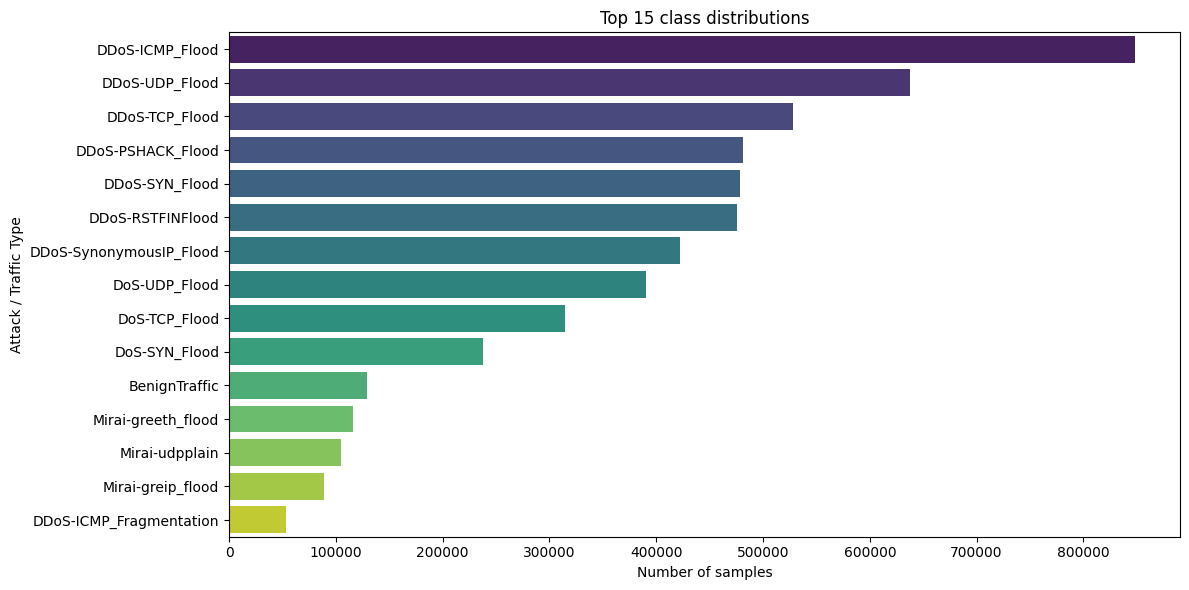

In [11]:
# Label Distribution Analysis
plt.figure(figsize=(12,6))
top_labels=df['label'].value_counts().head(15)

sns.barplot(x=top_labels.values, y=top_labels.index, palette='viridis')
plt.title('Top 15 class distributions')
plt.xlabel('Number of samples')
plt.ylabel('Attack / Traffic Type')
plt.tight_layout()
plt.show()

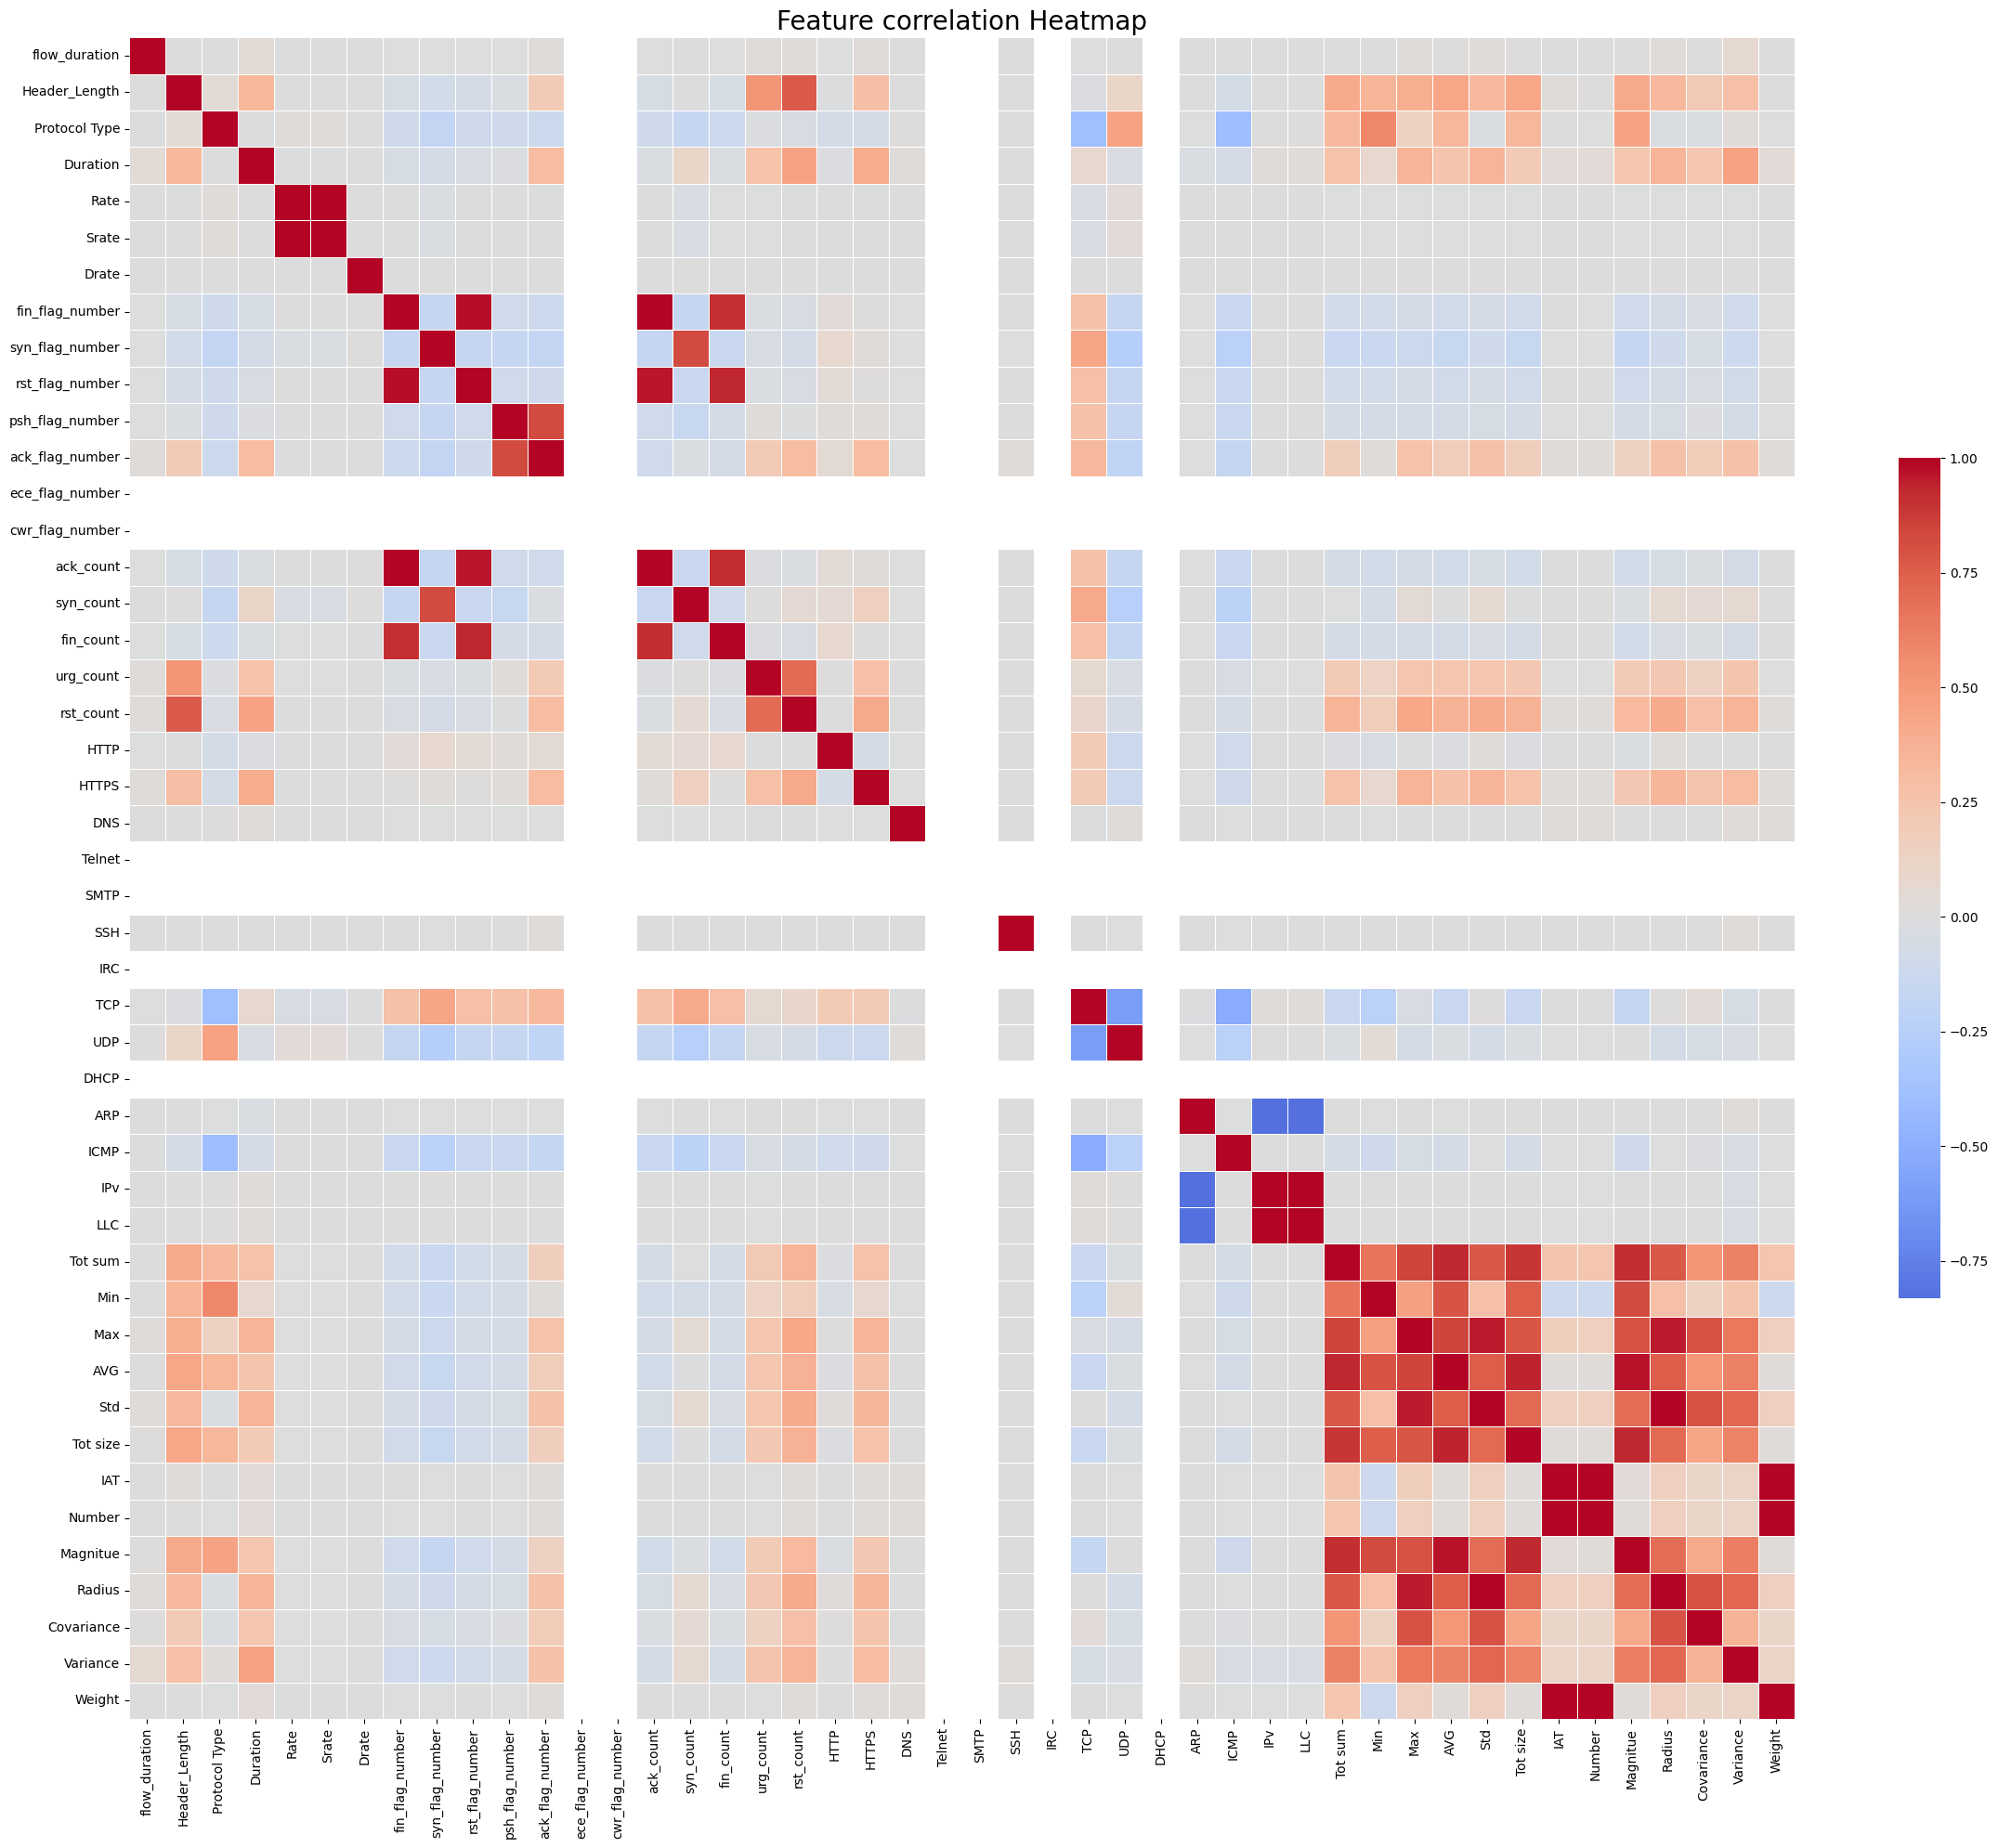

In [12]:
# correlation matrix (finding redundant features)
df_sample = df.sample(n=100000, random_state=42)

# droping the categorical column 'label' before calculating correlation
numeric_df = df_sample.drop(columns=['label'], errors='ignore')

corr_matrix = numeric_df.corr()

# creating a mask to show only the lower triangle
# mask = np.triu(np.ones_like(corr_matrix,dtype=bool))

plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=.5, cbar_kws={'shrink': .5})
plt.title('Feature correlation Heatmap', fontsize=20)
plt.tight_layout()
plt.show()

In [13]:
# Identifying the highly correlated features to drop
# if two features have a correlation > 0.95, they are providing the exact same information.
threshold=0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > threshold)]

print(f'{len(to_drop)} features are highly correlated')
print(to_drop)

9 features are highly correlated
['Srate', 'rst_flag_number', 'ack_count', 'LLC', 'Std', 'Number', 'Magnitue', 'Radius', 'Weight']


In [14]:
df_cleaned = df.drop(columns=to_drop, errors='ignore')

print('original df shape', df.shape)
print('cleaned df shape', df_cleaned.shape)

original df shape (5491971, 47)
cleaned df shape (5491971, 38)


In [15]:
# Identifying zero-variance features
# if a feature has a std of 0, it holds the same value for every single packet
variances = numeric_df.std()
zero_variance_cols = variances[variances == 0].index.tolist()

if len(zero_variance_cols) > 0:
  print('These features never change', zero_variance_cols)


These features never change ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']


In [16]:
df_cleaned.drop(columns=zero_variance_cols, inplace=True, errors='ignore')
print('df_cleaned shape', df_cleaned.shape)

df_cleaned shape (5491971, 32)


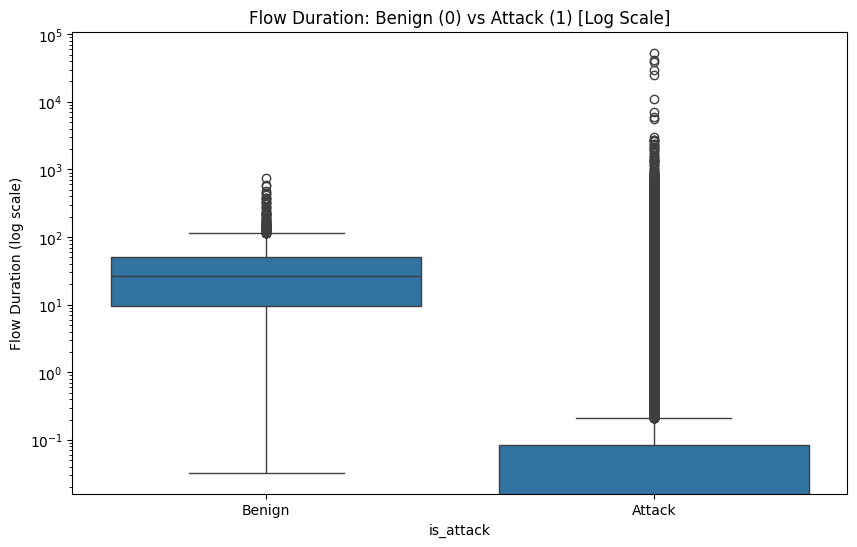

In [17]:
# comparing benign vs attack on a specific feature e.g flow_duration
df_sample['is_attack'] = df_sample['label'].apply(lambda x: 0 if x == 'BenignTraffic' else 1)

plt.figure(figsize=(10,6))
sns.boxplot(data=df_sample, x = 'is_attack', y='flow_duration')
plt.yscale('log')
plt.title('Flow Duration: Benign (0) vs Attack (1) [Log Scale]')
plt.xticks([0,1] , ['Benign', 'Attack'])
plt.ylabel('Flow Duration (log scale)')
plt.show()

In [18]:
df_cleaned['is_attack'] = df_cleaned['label'].apply(lambda x: 0 if x == 'BenignTraffic' else 1)

benign_data = df_cleaned[df_cleaned['is_attack'] == 0]
attack_data = df_cleaned[df_cleaned['is_attack'] == 1]

# X_benign = benign_data.drop(columns=['label'])


In [19]:
# we need a pure benign set for training the baseline (e.g 80,000 samples)
# and we will put the rest of the benign traffic + some attack into the test set

X_benign_train, X_benign_test = train_test_split(benign_data, test_size=0.2, random_state=42)

# sample attack for testing (e.g 50,000 samples)
X_attack_test = attack_data.sample(n=50000, random_state=42)

test_data = pd.concat([X_benign_test, X_attack_test])
X_test = test_data.drop(columns=['label', 'is_attack'])
y_test = test_data['is_attack']

X_train = X_benign_train.drop(columns=['label', 'is_attack'])

In [20]:
# Scaling the data
# fit the RobustScaler only on the normal traffic
# this teaches the scalar what 'normal' looks like without attack outliers ruining the math
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# contamination = 'auto' because our training data is 100% pure benign
iso_forest = IsolationForest(n_estimators=300, contamination='auto', max_samples=256, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_scaled)

IsolationForest(max_samples=256, n_estimators=300, n_jobs=-1, random_state=42)

In [22]:
# custom threshold tuning

# get raw anomaly scores (negatie values means more anomalies)
# we multiply by -1 so that higher score = more anomalies
anomaly_scores = -iso_forest.score_samples(X_test_scaled)

# Calculate Precision-Recall curve to find the absolute best mathematical threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, anomaly_scores)

# calculate f1 score for each threshold and find the best one
f1_scores = 2 * (precisions* recalls) / (precisions + recalls + 1e-10)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]

print(f'optimized anomaly threshold: {best_threshold:.4f}')

optimized anomaly threshold: 0.4686


<Axes: ylabel='Count'>

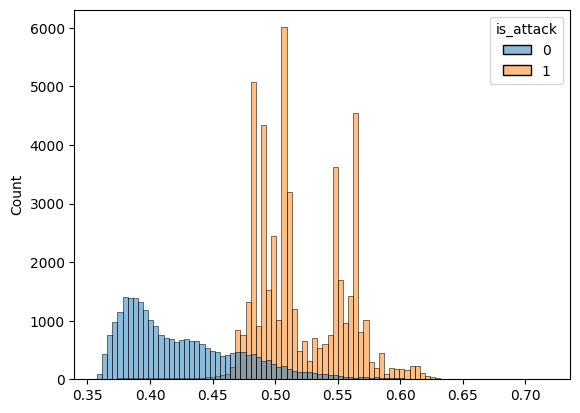

In [23]:
sns.histplot(data=test_data, x=anomaly_scores, hue=y_test)

Classification Report

              precision    recall  f1-score   support

  Benign (0)       0.96      0.81      0.88     25908
  Attack (1)       0.91      0.98      0.94     50000

    accuracy                           0.92     75908
   macro avg       0.93      0.89      0.91     75908
weighted avg       0.92      0.92      0.92     75908



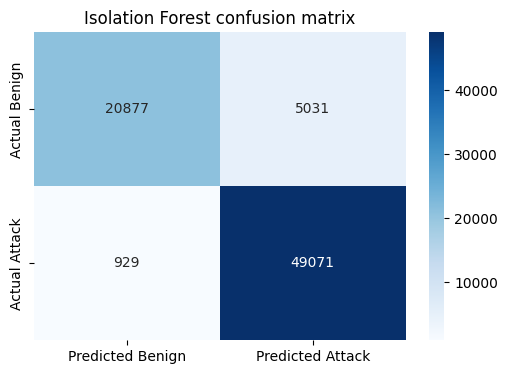

In [24]:
# Final Evaluation
# if score > best_threshold, flag as attack (1), else benign (0)
final_predictions = (anomaly_scores > best_threshold).astype(int)

print('Classification Report\n')

print(classification_report(y_test, final_predictions, target_names=['Benign (0)', 'Attack (1)']))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Benign', 'Predicted Attack'], yticklabels=['Actual Benign', 'Actual Attack'])

plt.title('Isolation Forest confusion matrix')
plt.show()


In [25]:
import joblib
joblib.dump(iso_forest, 'isolation_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']